# **Swiggy Sales Analysis**

### Importing required libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

### Importing Data in python

In [13]:
df = pd.read_csv("E:/Data Analysis/PowerBi/Project/Swiggy Data Analytis/Dataset/swiggy_all_menus_india.csv")

In [14]:
df.head()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


In [15]:
df.tail()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
197425,Sikkim,Gangtok,2025-01-25,Mama's Kitchen,Gangtok,Momos,Soya cheese chilli momo ...,112.0,4.4,0
197426,Sikkim,Gangtok,2025-07-02,Mama's Kitchen,Gangtok,Momos,Kurkure momo fried ...,140.0,4.4,0
197427,Sikkim,Gangtok,2025-03-25,Mama's Kitchen,Gangtok,Momos,Chilli cheese momo,126.0,4.4,0
197428,Sikkim,Gangtok,2025-03-26,Mama's Kitchen,Gangtok,Momos,Veg Momos (8 Pc),85.0,4.4,0
197429,Sikkim,Gangtok,2025-03-27,Mama's Kitchen,Gangtok,Momos,Soya Momo,100.0,4.4,0


### Identifying Metadata

In [16]:
print("Number of Rows Available: - ",df.shape[0])

Number of Rows Available: -  197430


In [17]:
print("Number of Columns Available: - ",df.shape[1])

Number of Columns Available: -  10


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197430 entries, 0 to 197429
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   State            197430 non-null  object 
 1   City             197430 non-null  object 
 2   Order Date       197430 non-null  object 
 3   Restaurant Name  197430 non-null  object 
 4   Location         197430 non-null  object 
 5   Category         197430 non-null  object 
 6   Dish Name        197430 non-null  object 
 7   Price (INR)      197430 non-null  float64
 8   Rating           197430 non-null  float64
 9   Rating Count     197430 non-null  int64  
dtypes: float64(2), int64(1), object(7)
memory usage: 15.1+ MB


## Cheking Data Types

### Order_date datatype change to Datetime

In [20]:
df.dtypes

State               object
City                object
Order Date          object
Restaurant Name     object
Location            object
Category            object
Dish Name           object
Price (INR)        float64
Rating             float64
Rating Count         int64
dtype: object

In [24]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [25]:
df.dtypes

State                      object
City                       object
Order Date         datetime64[ns]
Restaurant Name            object
Location                   object
Category                   object
Dish Name                  object
Price (INR)               float64
Rating                    float64
Rating Count                int64
dtype: object

In [26]:
df.describe()

,Order Date,Price (INR),Rating,Rating Count
count,197430,197430.000000,197430.000000,197430.000000
mean,2025-05-01 19:41:20.996808960,268.512920,4.341582,28.321805
min,2025-01-01 00:00:00,0.950000,1.500000,0.000000
25%,2025-03-01 00:00:00,139.000000,4.300000,0.000000
50%,2025-05-02 00:00:00,229.000000,4.400000,2.000000
75%,2025-07-01 00:00:00,329.000000,4.500000,15.000000
max,2025-08-31 00:00:00,8000.000000,5.000000,999.000000
std,NaN,219.338363,0.422585,87.542593


# KPI's

### Total Sales

In [27]:
Total_Sales = df['Price (INR)'].sum()
print("Total Sale in INR is: -",round(Total_Sales,2))

Total Sale in INR is: - 53012505.77


### Average Rating

In [28]:
Average_Rating = df['Rating'].mean()
print("Average Rating is: - ",round(Average_Rating,1))

Average Rating is: -  4.3


### Average Order Value

In [29]:
Avg_order_value = df["Price (INR)"].mean()
print("Average Order Value is: - ",round(Avg_order_value,2))

Average Order Value is: -  268.51


### Rating Count

In [30]:
Rating_Count = df['Rating Count'].sum()
print("Rating count is: - ",Rating_Count)

Rating count is: -  5591574


### Total Orders

In [31]:
Total_Orders = len(df)
print("Total Length of order is: - ", Total_Orders)

Total Length of order is: -  197430


## Chart Designs

### Monthly Sales Analysis

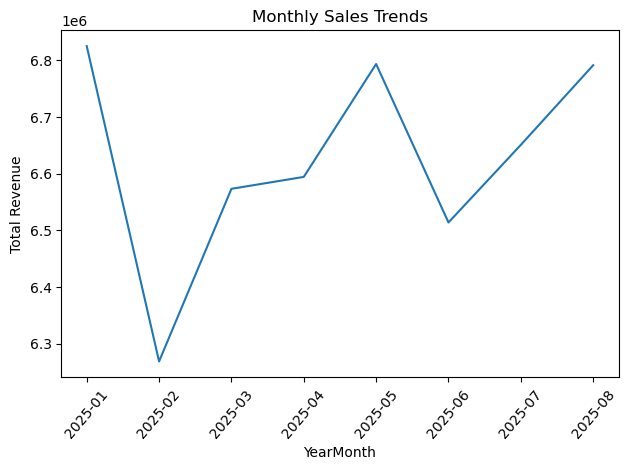

In [34]:
df["Order Date"] = pd.to_datetime(df['Order Date'])
df["YearMonth"] = df["Order Date"].dt.to_period("M").astype(str)
monthly_sales = df.groupby("YearMonth")["Price (INR)"].sum().reset_index()
plt.figure()
plt.plot(monthly_sales["YearMonth"], monthly_sales["Price (INR)"])
plt.xlabel("YearMonth")
plt.ylabel("Total Revenue")
plt.title("Monthly Sales Trends")
plt.xticks(rotation = 50)
plt.tight_layout()
plt.show()

### Daily Sales Analysis

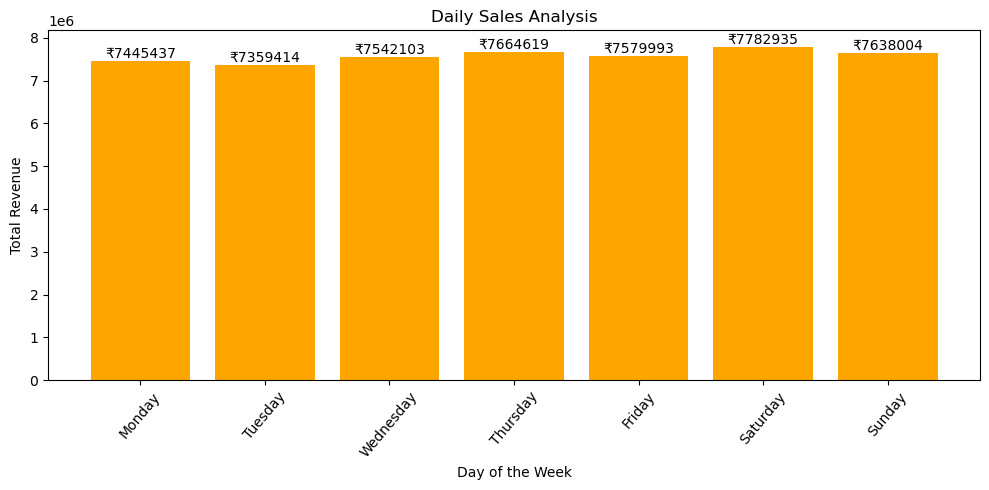

In [35]:
df["DayName"] = pd.to_datetime(df["Order Date"]).dt.day_name()
Daily_sales = (
     df.groupby("DayName")["Price (INR)"].sum()
    .reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
  )

plt.figure(figsize = (10,5))
Bars = plt.bar(Daily_sales.index, Daily_sales.values,color = 'Orange')
plt.xlabel("Day of the Week")
plt.ylabel("Total Revenue")
plt.title("Daily Sales Analysis")
plt.xticks(rotation = 50)
plt.bar_label(Bars, fmt = '₹%.0f')
plt.tight_layout()
plt.show()

### Sales by Food Type (Veg vs Non-Veg)

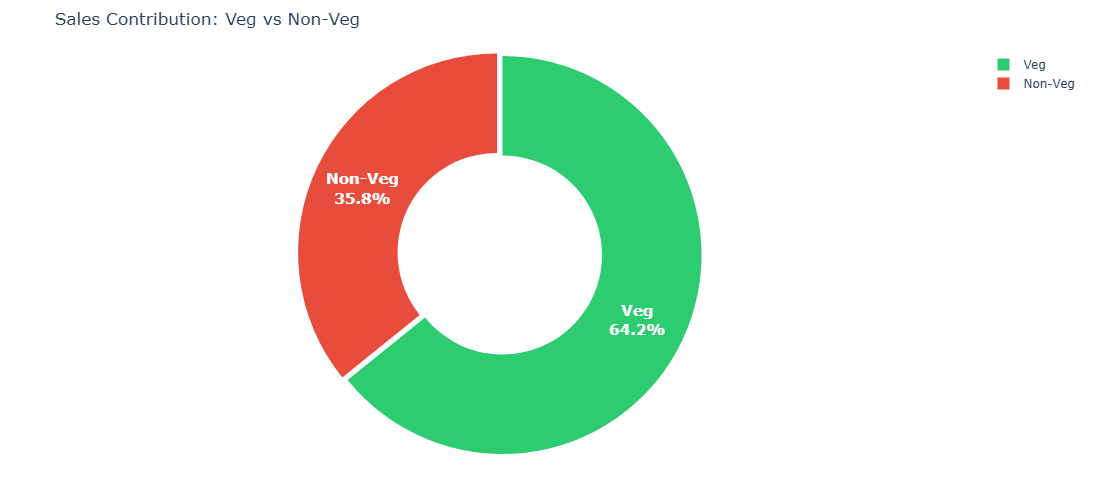

In [36]:
Non_Veg_Keywords = [
       "chicken","mutton","fish","egg","prawn","biryani",
       "turkey","duck","pork","crab","lobster","squid","bacon",
       "sausage","salami","haleem"
]

df["Food Category"] = np.where(
    df["Dish Name"].str.lower().str.contains("|".join(Non_Veg_Keywords),na=False),
    "Non-Veg",
    "Veg"
)

Food_Revenue = (
    df.groupby("Food Category")["Price (INR)"].sum()
    .reset_index()
)

figure = px.pie(
    Food_Revenue,
    names = "Food Category",
    values = "Price (INR)",
    title = "Sales Contribution: Veg vs Non-Veg",
    hole = 0.5,
    color = "Food Category",
    color_discrete_map={
         "Veg": "#2ECC71",     # for light green color
         "Non-Veg": "#E74C3C"  # For light red color
    }
)

pull = [0.03 if food == "Non-Veg" else 0.0 for food in Food_Revenue["Food Category"]]

figure.update_traces(
    textposition = "inside",
    textinfo = "percent+label",
    pull = pull,
    textfont = dict(size = 15, color = "white", weight = "bold")
    )

figure.update_layout(
    height = 500,
    margin = dict(t=50,l=40,r=40,b=40)
)
figure.show()

### Sales by States

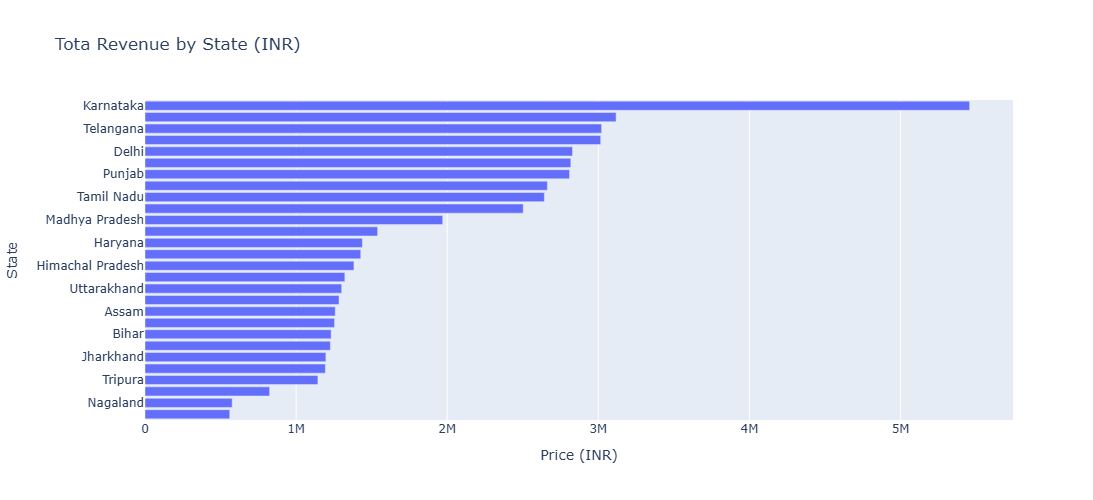

In [37]:
Figure = px.bar(
    df.groupby("State", as_index = False)["Price (INR)"].sum()
    .sort_values("Price (INR)", ascending = False),
    x = "Price (INR)",
    y = "State",
    orientation = "h",
    title = "Tota Revenue by State (INR)"
)

Figure.update_layout( height = 500,yaxis = dict(autorange = "reversed"))
Figure.show()

### Quarterly Performance Summery

In [38]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Quarter"] = df["Order Date"].dt.to_period("Q").astype(str)
quarterly_summery = (
    df.groupby("Quarter", as_index = False)
    .agg(
        Total_Sales = ("Price (INR)", "sum"),
        Total_Orders = ("Order Date", "count"),
        Average_Rating = ("Rating", "mean")
    )
    .sort_values("Quarter")
)

quarterly_summery["Average_Rating"] = quarterly_summery["Average_Rating"].round(1)

quarterly_summery

,Quarter,Total_Sales,Total_Orders,Average_Rating
0,2025Q1,19667821.77,73096,4.3
1,2025Q2,19902256.59,74163,4.3
2,2025Q3,13442427.41,50171,4.3


### Top 5 Cities by Sales

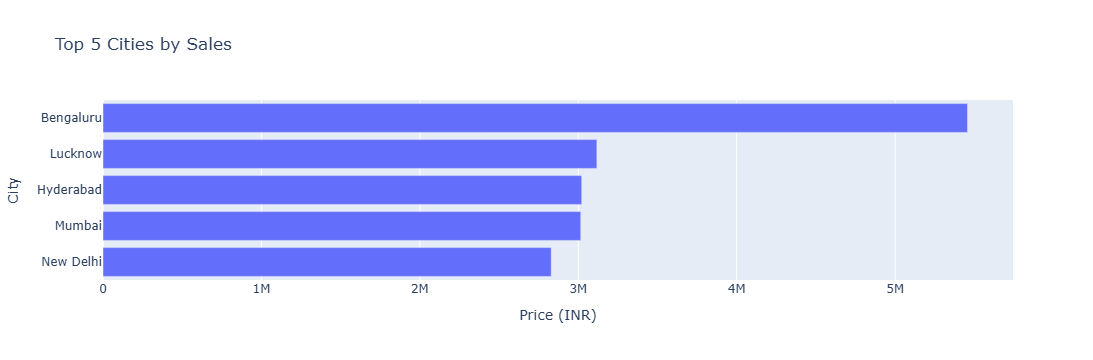

In [39]:
Top_5_Cities = (
    df.groupby("City")["Price (INR)"].sum()
    .nlargest(5)
    .sort_values()
    .reset_index()
)

Figure = px.bar(
    Top_5_Cities,
    x = "Price (INR)",
    y = "City",
    orientation = "h",
    title = "Top 5 Cities by Sales",
    color_discrete_sequence = ['Light Blue']
)

Figure.show()

### Weekly Trend Analysis

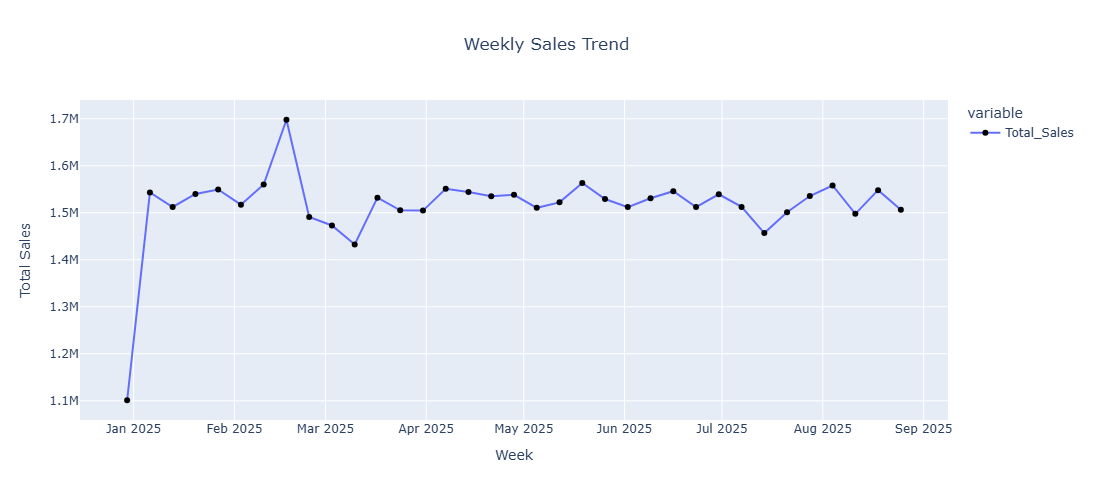

In [40]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["Week"] = df["Order Date"].dt.to_period("W").astype(str)

df["Week_Start"] = df["Order Date"].dt.to_period("W").apply(lambda r: r.start_time)

Weekly_Summery = (
    df.groupby("Week_Start", as_index = False)
    .agg(
        Total_Sales = ("Price (INR)", "sum"),
        Total_Orders = ("Order Date", "count"),
        Average_Rating = ("Rating", "mean")
)
    .sort_values("Week_Start")
)

Figure = px.line(
    Weekly_Summery,
    x = "Week_Start",
    y = ["Total_Sales"],
    title = "Weekly Sales Trend",
    markers = True,
    color_discrete_sequence = ['Light Blue']
)

Figure.update_layout(
    height = 500,
    xaxis_title = "Week",
    yaxis_title = "Total Sales",
    title = dict(x = 0.5)
)


Figure.show()